# 10.2 変分ベイズ混合ガウスモデル (Variational Gaussian Mixtures)

本ノートブックでは、最尤推定における深刻な特異点（特異解）を根本的に克服し、**データから最適なクラスタ数を自動決定 (Automatic Relevance Determination)** する**完全ベイズ型混合ガウスモデルの変分推論 (Variational Bayesian GMM)** を学びます。

混合ガウスモデル (GMM) の最尤推定には、「成分の一つが単一のデータポイントに潰れると分散がゼロになり尤度が無限大に発散する」という**特異点 (Singularity)** の問題がありました。また、クラスタ数 $K$ は事前知識として与えるか、クロスバリデーション等で外部から決定する必要がありました。
完全ベイズ的アプローチと変分推論を組み合わせることで、特異点を回避しつつ、単一の訓練プロセスの中で最適なクラスタ数を自動的に見つけ出すことが可能になります。

本ノートブックでは、ディリクレ・ガウス・ウィシャート共役事前分布の導入、変分EMアルゴリズムにおける各パラメータの更新式の導出を追跡し、Old Faithful 間欠泉データにおいて過剰な $K=6$ 成分で開始しても**不要な4成分が自律的にゼロへ消滅して $K=2$ に自動収縮する現象（PRML Figure 10.6）**、および変分下界 $\mathcal{L}(q)$ によるクラスタ数評価（**PRML Figure 10.7**）を完全実装・再現します。

## 10.2 変分混合ガウスモデルとクラスタ数の自動決定 (PRML Figure 10.6)

### ベイズ的定式化と事前分布

潜在変数 $\mathbf{Z} = \{\mathbf{z}_n\}$（各データポイントのクラスタ割り当て）に加え、パラメータ $\boldsymbol{\pi}$（混合比）、$\boldsymbol{\mu} = \{\boldsymbol{\mu}_k\}$（各成分の平均）、$\boldsymbol{\Lambda} = \{\boldsymbol{\Lambda}_k\}$（各成分の精度行列）すべてに事前分布を導入し、確率変数として扱います。

混合比 $\boldsymbol{\pi}$ にはディリクレ事前分布を、各成分の平均と精度 $(\boldsymbol{\mu}_k, \boldsymbol{\Lambda}_k)$ にはガウス・ウィシャート事前分布を導入します（共役事前分布）：
$$ p(\boldsymbol{\pi}) = \mathrm{Dir}(\boldsymbol{\pi} | \alpha_0) = C(\alpha_0) \prod_{k=1}^K \pi_k^{\alpha_0 - 1} $$
$$ p(\boldsymbol{\mu}_k, \boldsymbol{\Lambda}_k) = p(\boldsymbol{\mu}_k | \boldsymbol{\Lambda}_k) p(\boldsymbol{\Lambda}_k) = \mathcal{N}(\boldsymbol{\mu}_k | \mathbf{m}_0, (\beta_0 \boldsymbol{\Lambda}_k)^{-1}) \mathcal{W}(\boldsymbol{\Lambda}_k | \mathbf{W}_0, \nu_0) $$

### 因数分解近似分布と変分EMアルゴリズム

事後分布 $p(\mathbf{Z}, \boldsymbol{\pi}, \boldsymbol{\mu}, \boldsymbol{\Lambda} | \mathbf{X})$ に対し、パラメータと潜在変数が独立であるとする平均場近似（因数分解変分分布）を仮定します：
$$ q(\mathbf{Z}, \boldsymbol{\pi}, \boldsymbol{\mu}, \boldsymbol{\Lambda}) = q(\mathbf{Z}) q(\boldsymbol{\pi}, \boldsymbol{\mu}, \boldsymbol{\Lambda}) = q(\mathbf{Z}) q(\boldsymbol{\pi}) \prod_{k=1}^K q(\boldsymbol{\mu}_k, \boldsymbol{\Lambda}_k) $$

変分推論の一般更新式 $\ln q_j^*(\mathbf{Z}_j) = \mathbb{E}_{i \neq j}[\ln p(\mathbf{X}, \mathbf{Z})] + \mathrm{const}$ を用いることで、各因子の最適解が連立方程式の形で得られます。これは**変分EMアルゴリズム**として機能します。

**変分Eステップ (E-step):**
潜在変数 $\mathbf{Z}$ に関する更新を行います。負担率 $r_{nk} = q(z_{nk}=1)$ は次のように更新されます：
$$ r_{nk} = \frac{\rho_{nk}}{\sum_{j=1}^K \rho_{nj}} $$
ここで、$\ln \rho_{nk} = \mathbb{E}[\ln \pi_k] + \frac{1}{2}\mathbb{E}[\ln |\boldsymbol{\Lambda}_k|] - \frac{D}{2}\ln(2\pi) - \frac{1}{2}\mathbb{E}_{\boldsymbol{\mu}_k, \boldsymbol{\Lambda}_k}[(\mathbf{x}_n - \boldsymbol{\mu}_k)^T \boldsymbol{\Lambda}_k (\mathbf{x}_n - \boldsymbol{\mu}_k)]$ です。

**変分Mステップ (M-step):**
パラメータに関する更新を行います。各分布の形は事前分布と同じ関数形（ディリクレ分布、ガウス・ウィシャート分布）を保ちます：
- $q^*(\boldsymbol{\pi}) = \mathrm{Dir}(\boldsymbol{\pi} | \boldsymbol{\alpha})$
- $q^*(\boldsymbol{\mu}_k, \boldsymbol{\Lambda}_k) = \mathcal{N}(\boldsymbol{\mu}_k | \mathbf{m}_k, (\beta_k \boldsymbol{\Lambda}_k)^{-1}) \mathcal{W}(\boldsymbol{\Lambda}_k | \mathbf{W}_k, \nu_k)$

ここで、更新されたハイパーパラメータは、データから得られる十分統計量（$N_k = \sum_n r_{nk}$ など）を用いて計算されます。例えば：
$$ \alpha_k = \alpha_0 + N_k $$
$$ \beta_k = \beta_0 + N_k, \quad \mathbf{m}_k = \frac{1}{\beta_k} (\beta_0 \mathbf{m}_0 + N_k \bar{\mathbf{x}}_k) $$

### 不要な成分の自動間引き (Sparsity and Bayesian Occam's Razor)

事前ハイパーパラメータ $\alpha_0 \to 0$（無情報または疎な事前分布）を設定すると、モデルは不要な成分を排除しようと働きます。データによって支持されないクラスタ $k$ に対しては、負担率の和である実効データ数 $N_k \approx 0$ となります。
すると、事後パラメータは $\alpha_k \approx \alpha_0 \approx 0$ となり、**期待混合比 $\mathbb{E}[\pi_k] = \frac{\alpha_k}{\sum \alpha_j} \to 0$ へと縮退して自動的に消滅します**。

これは「ベイズのオッカムの剃刀 (Bayesian Occam's Razor)」の現れであり、モデルの複雑さに対して自動的にペナルティが課されるためです。過剰なクラスタを持たせると事前分布から外れるため周辺尤度が下がり、結果として変分推論は不要なコンポーネントをプルーニング（刈り込み）することで最適なモデル構造を自律的に発見します。

Effective Component Weights E[pi_k] for K=6 components:
Component 1: E[pi] = 0.0000 (alpha_k = 0.00)
Component 2: E[pi] = 0.0000 (alpha_k = 0.00)
Component 3: E[pi] = 0.0000 (alpha_k = 0.00)
Component 4: E[pi] = 0.3571 (alpha_k = 97.14)
Component 5: E[pi] = 0.6429 (alpha_k = 174.86)
Component 6: E[pi] = 0.0000 (alpha_k = 0.00)
Number of active components automatically retained: 2 (Expected: 2)
Plot saved to: result/fig10_6_variational_gmm_faithful.png


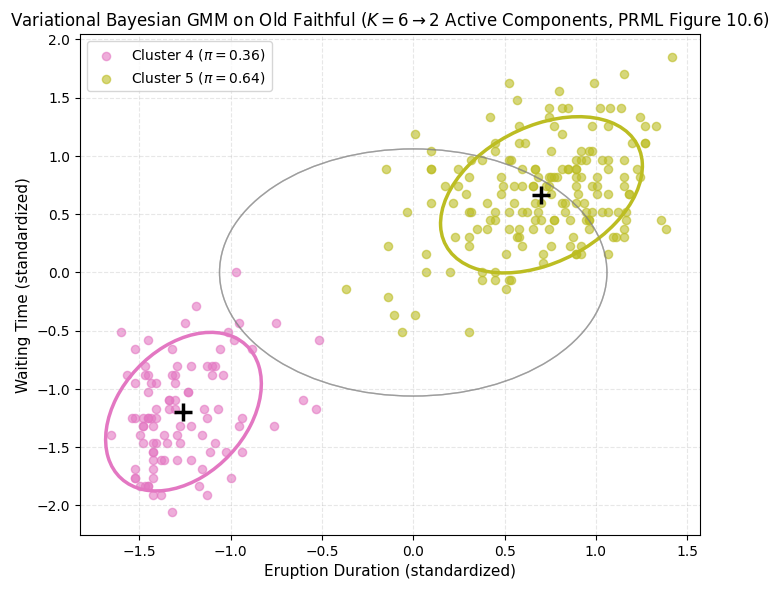

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from common.plot_utils import save_plot, setup_style
from common.variational_utils import VariationalGaussianMixture
setup_style()

# 楕円描画ユーティリティ
def plot_gaussian_ellipse(ax, mean, cov, n_std=1.5, color='crimson', lw=2.0, alpha=0.8):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * n_std * np.sqrt(np.maximum(vals, 1e-8))
    ell = Ellipse(xy=mean, width=w, height=h, angle=theta, edgecolor=color, fc='none', lw=lw, alpha=alpha, zorder=4)
    ax.add_patch(ell)

# Old Faithful データの準備
df = pd.read_csv('../common/faithful.csv')
X_raw = df[['duration', 'waiting']].values
X = (X_raw - np.mean(X_raw, axis=0)) / np.std(X_raw, axis=0)
N, D = X.shape

# PRML Figure 10.6: 過剰な K=6 成分、alpha_0 = 1e-3 で変分GMMを実行
K_init = 6
vgm = VariationalGaussianMixture(n_components=K_init, alpha_0=1e-3, beta_0=1.0, max_iter=80, random_state=42)
vgm.fit(X)

# 各成分の事後混合比期待値 E[pi_k] = alpha_k / sum(alpha)
E_pi = vgm.alpha_ / np.sum(vgm.alpha_)
print("Effective Component Weights E[pi_k] for K=6 components:")
for k in range(K_init):
    print(f"Component {k+1}: E[pi] = {E_pi[k]:.4f} (alpha_k = {vgm.alpha_[k]:.2f})")

# 有効な成分 (E[pi] > 0.05) の抽出
active_components = np.where(E_pi > 0.05)[0]
print(f"Number of active components automatically retained: {len(active_components)} (Expected: 2)")

# PRML Figure 10.6 のプロット
fig, ax = plt.subplots(figsize=(8, 6.5))

# データ点のプロット (負担率に基づく色分け)
labels = np.argmax(vgm.responsibilities_, axis=1)
colors = plt.cm.tab10(np.linspace(0, 1, K_init))

for k in range(K_init):
    pts = X[labels == k]
    if len(pts) > 0:
        ax.scatter(pts[:, 0], pts[:, 1], color=colors[k], alpha=0.6, s=35, label=f'Cluster {k+1} ($\pi={E_pi[k]:.2f}$)')
    
    # 共分散 (精度行列の逆行列: E[Lambda_k]^-1 = (nu_k * W_k)^-1)
    cov_k = np.linalg.inv(vgm.nu_[k] * vgm.W_[k])
    # 有効成分は太い実線、消滅成分は薄い点線
    if E_pi[k] > 0.05:
        plot_gaussian_ellipse(ax, vgm.m_[k], cov_k, n_std=1.5, color=colors[k], lw=2.5, alpha=1.0)
        ax.scatter(vgm.m_[k, 0], vgm.m_[k, 1], marker='+', s=150, color='black', lw=2.5, zorder=5)
    else:
        plot_gaussian_ellipse(ax, vgm.m_[k], cov_k, n_std=1.5, color='gray', lw=1.0, alpha=0.3)

ax.set_title(r'Variational Bayesian GMM on Old Faithful ($K=6 \to 2$ Active Components, PRML Figure 10.6)', fontsize=12)
ax.set_xlabel('Eruption Duration (standardized)', fontsize=11)
ax.set_ylabel('Waiting Time (standardized)', fontsize=11)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig10_6_variational_gmm_faithful.png')
plt.show()